# **Blackjack com aprendizado de política**

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pickle
from collections import defaultdict

## **Treinando agente por Q-Learning**

Antes de implementar a função para rodar os episódios, vamos lembrar as ações e o que representa o estado do agente neste ambiente.

**Ações**:
- hit(1) => pedir outra carta
- stick(0) => ficar só com as cartas atuais

**Estado**: (player_sum, dealer_showing, usable_ace: bool)
- player_sum => soma atual dos valores das cartas que o agente tem em mãos
- dealer_showing => soma dos valores das cartas do dealer (só as que ele está mostrando)
- usable_ace => se o agente tem um às em mãos, diz que ele pode valer como 11 para completar o 21

In [7]:
def run(episodes, render=False):
    env = gym.make('Blackjack-v1', render_mode='human' if render else None)

    '''
    q é um dicionário em que a chave é o estado (a tupla obs) e o valor é um vetor de q-values por ação

    como o estado é a tupla (player_sum, dealer_showing, usable_ace), devemos ter algo coo q[(16, 10, False)] -> array([Q_stick, Q_hit])

    na prática, a q-table seria algo como:
    {
        (12, 5, False): [ -0.02,  0.15],
        (20, 10, False): [ 0.00, -0.35],
        (13, 1, True):   [ -0.10, 0.05],
        ...
    }
    '''
    q = defaultdict(lambda: np.zeros(env.action_space.n))

    rewards_per_episode = np.zeros(episodes)


    '''hiperparâmetros'''
    learning_rate_a = 0.25            # alpha ou learning rate
    discount_factor_g = 0.99         # gamma ou discount rate. Near 0: more weight/reward placed on immediate state. Near 1: more on future state
    epsilon = 1.0                    # 1 = 100% random actions
    epsilon_decay_rate = epsilon / (episodes / 2)
    epsilon_min = 0.05
    rng = np.random.default_rng()    # random number generator


    for i in range(episodes):
        obs = env.reset()       # env.reset() retorna (obs, info) e queremos apenas a primeira
        obs = obs[0]
        terminated = False      # True quando a partida acaba (ganhando ou perdendo)
        truncated = False


        while(not terminated and not truncated):
            '''
            se o número aleatório gerado for menor que epsilon, a ação tomada é aleatória,
            caso contrário, seguirá a Q-Table
            '''
            if rng.random() < epsilon:
                action = env.action_space.sample() # actions: 1=hit (pedir carta) 0=stick (ficar)
            else:
                # vai na entrada do estado atual e vê qual é a ação com maior valor
                action = np.argmax(q[obs])       # seleciona a posição da tabela com maior pontuação

            new_obs, reward, terminated, truncated, _ = env.step(action)


            '''fórmula para calcular os elementos da Q-Table'''
            q[obs][action] = q[obs][action] + learning_rate_a * (
                        reward + discount_factor_g * np.max(q[new_obs]) - q[obs][action])
            
            obs = new_obs


        '''depois de cada episódio, reduzimos o epsilon até que ele seja zero (em algum momento)'''
        epsilon = max(epsilon * epsilon_decay_rate, epsilon_min)

        if reward == 1:
            rewards_per_episode[i] = 1

    env.close()


    '''plotar o gráfico da porcentagem de recompensas(episódios)'''
    win_rate = np.zeros(episodes)
    for t in range(episodes):
        window = rewards_per_episode[max(0, t-100):(t+1)]
        win_rate[t] = np.mean(window) * 100
    plt.plot(win_rate)
    plt.xlabel("Episodes")
    plt.ylabel("Episode Rewards")
    plt.savefig('blackjack.png')


    '''salvando a q-table em arquivo para poder usá-la após o treinamento'''
    f = open("blackjack.pkl","wb")
    pickle.dump(dict(q), f)
    f.close()

    return q

### **Rodando os episódios**

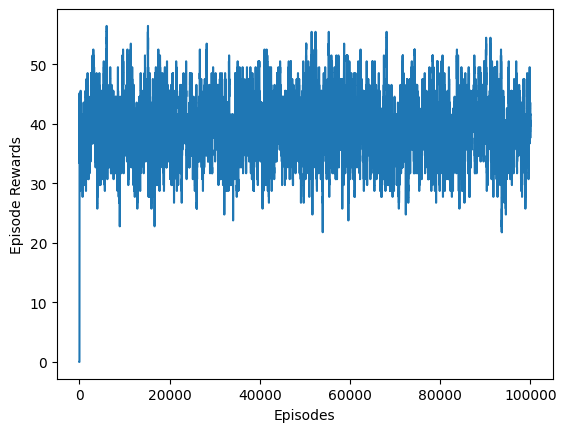

In [8]:
if __name__ == '__main__':
    q = run(100000)

**O que é um ás "usável" nesse ambiente?**

Um ás vale 11 pontos, a menos que isso faria o jogador estourar (> 21).
Se todos os ases da mão precisam valer 1 para evitar o estouro, então não há ás usável (usable_ace = False).

Ex.:
- mão (A, 7) = 18 com ás como 11 → usável
- mão (A, 7, 5) = 13 (ás virou 1) → não usável
- mão (A, 2, 3) = 16 com ás como 11 → usável

## **Visualizando a distribuição de ações**

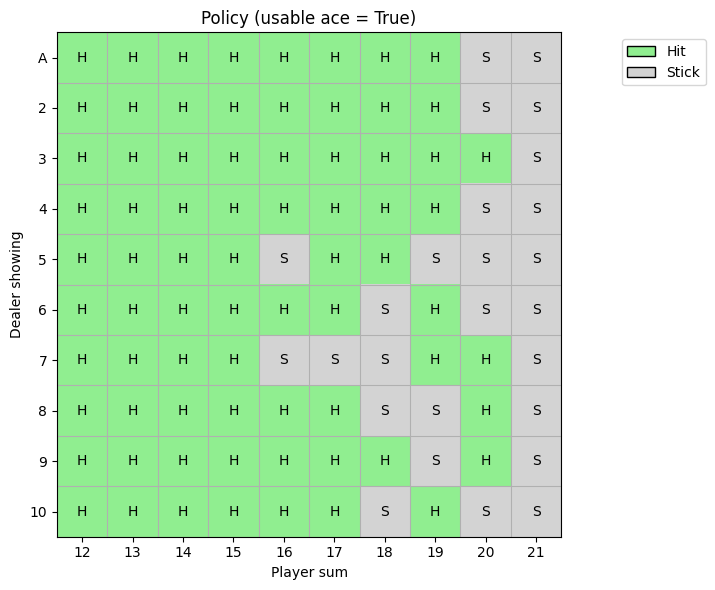

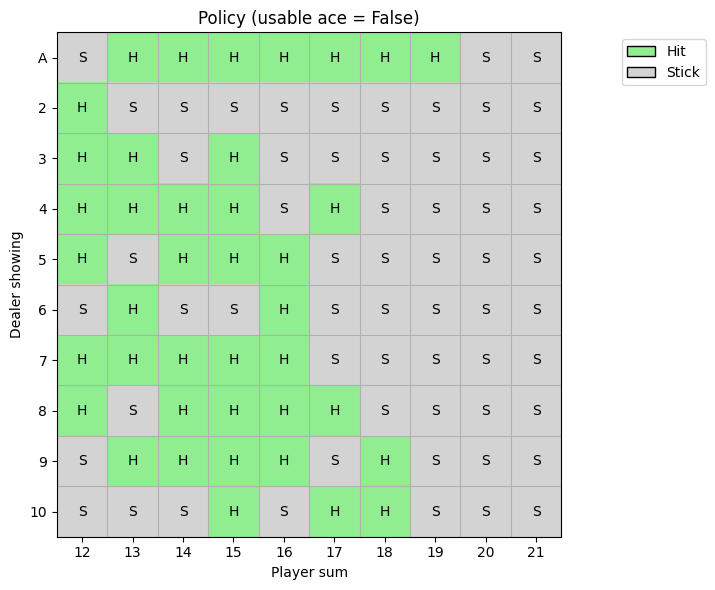

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.colors as mcolors


def build_policy_array(q, usable_ace=False, hit_until=20):
    """
    retorna (grid, players, dealers) para plot:
      - grid: matriz 10x10 com 0 (S) ou 1 (H)
      - players: [12..21] (eixo X)
      - dealers: [1..10]  onde 1 = Ás (eixo Y)
    """
    dealers = np.arange(1, 11)    # 1 = Ás
    players = np.arange(12, 22)   # 12..21
    grid = np.zeros((len(dealers), len(players)), dtype=int)

    for i, d in enumerate(dealers):
        for j, p in enumerate(players):
            s = (int(p), int(d), bool(usable_ace))
            if s in q:
                a = int(np.argmax(q[s]))     # 0=S, 1=H
            else:
                a = 1 if p < hit_until else 0
            grid[i, j] = a
    return grid, players, dealers


def plot_policy_matplotlib(grid, players, dealers, title='Policy', savepath=None):
    '''
    plota a política como heatmap 2D.
        - nnota 'H'/'S' em cada célula.
        - eixos: X = soma do jogador (12..21), Y = carta visível do dealer (A,2..10)
    '''

    fig, ax = plt.subplots(figsize=(8, 6))

    # mapa de cores : 0 = cinza (stick), 1 = verde (hit)
    cmap = mcolors.ListedColormap(['lightgrey', 'lightgreen'])
    bounds = [-0.5, 0.5, 1.5]  # fronteiras entre categorias
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # mostrar a matriz
    im = ax.imshow(grid, origin='upper', aspect='equal', cmap=cmap, norm=norm)  # 0..1

    # ticks e rótulos
    ax.set_xticks(np.arange(len(players)))
    ax.set_yticks(np.arange(len(dealers)))
    ax.set_xticklabels(players)
    ax.set_yticklabels(['A'] + list(map(str, range(2, 11))))

    # linhas de grade leves
    ax.set_xticks(np.arange(-0.5, len(players), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(dealers), 1), minor=True)
    ax.grid(which='minor')
    ax.tick_params(which='minor', bottom=False, left=False)

    # anotações H/S nas células
    for i in range(len(dealers)):
        for j in range(len(players)):
            txt = 'H' if grid[i, j] == 1 else 'S'
            ax.text(j, i, txt, ha='center', va='center')

    ax.set_xlabel('Player sum')
    ax.set_ylabel('Dealer showing')
    ax.set_title(title)

    # legenda
    legend_elements = [
        Patch(facecolor="lightgreen", edgecolor="black", label="Hit"),
        Patch(facecolor="lightgrey", edgecolor="black", label="Stick"),
    ]
    ax.legend(handles=legend_elements, bbox_to_anchor=(1.3, 1))

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150)
    plt.show()

# ás usável como 11
grid_ua, players, dealers = build_policy_array(q, usable_ace=True)
plot_policy_matplotlib(grid_ua, players, dealers,
                       title='Policy (usable ace = True)',
                       savepath='policy_usable_ace.png')

# ás não usável como 11
grid_nua, players, dealers = build_policy_array(q, usable_ace=False)
plot_policy_matplotlib(grid_nua, players, dealers,
                       title='Policy (usable ace = False)',
                       savepath='policy_no_usable_ace.png')


### Por que a tabela com às usável tem muito mais hit do que stick?

Um ás usável conta como 11, mas pode ser rebaixado para 1 se você for “estourar”. Isso te dá margem de segurança: pedir carta (hit) é menos arriscado, pois o ás pode “amortecer” o estouro.

Sem ás usável (```usable_ace=False```), estourar é mais provável; então a política tende a parar (stick) mais cedo.